# **HR Analytics: Employee Attrition and Workforce Analysis**

## **Business Problem**

The HR department wants to understand employee attrition, salary trends, department performance, overtime patterns, and workforce insights to improve employee retention and business decisions.

### Objectives

The objective of this project is to analyze employee data to identify trends related to salary, attrition, employee satisfaction, promotions, and workforce characteristics. The insights generated from this analysis can support HR teams in improving employee retention and making data-driven decisions.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab

## Dataset Information

The dataset contains employee information including:

- Employee ID
- Department
- Age
- Gender
- Experience
- Salary
- Performance Rating
- Job Satisfaction
- Overtime
- Promotion
- Attrition

In [36]:
import pandas as pd

hr_data = {
    "EmployeeID": [101,102,103,104,105,106,107,108,109,110,111,112,113,114,115],
    "Name": ["Aman","Rahul","Neha","Ravi","Priya","Karan","Simran","Rohit","Anjali","Vikas","Pooja","Deepak","Sneha","Arjun","Nisha"],
    "Department": ["Sales","HR","IT","Finance","Sales","IT","Marketing","HR","Finance","Sales","Marketing","IT","HR","Sales","Finance"],
    "Age": [25,30,28,35,27,32,29,31,40,26,33,29,34,28,36],
    "Gender": ["Male","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female"],
    "Experience": [2,5,4,10,3,7,5,6,15,2,8,4,9,3,11],
    "Salary": [45000,60000,75000,90000,50000,80000,None,65000,95000,48000,72000,78000,68000,52000,98000],
    "PerformanceRating": [4,5,4,5,3,4,5,3,5,4,4,5,3,4,5],
    "JobSatisfaction": ["High","Medium","High","High","Low","Medium","High","Low","High","Medium","High","Medium","Low","Medium","High"],
    "Overtime": ["Yes","No","Yes","No","Yes","Yes","No","No","No","Yes","No","Yes","No","Yes","No"],
    "Promotion": ["No","Yes","No","Yes","No","Yes","No","No","Yes","No","Yes","No","No","No","Yes"],
    "Attrition": ["Yes","No","No","No","Yes","No","No","Yes","No","Yes","No","No","Yes","No","No"]
}

df = pd.DataFrame(hr_data)

df.loc[len(df)] = df.loc[4]

df.to_csv("HR_Data.csv", index=False)

print("Dataset Created Successfully!")

df.head()

Dataset Created Successfully!


,EmployeeID,Name,Department,Age,Gender,Experience,Salary,PerformanceRating,JobSatisfaction,Overtime,Promotion,Attrition
0,101,Aman,Sales,25,Male,2,45000.0,4,High,Yes,No,Yes
1,102,Rahul,HR,30,Male,5,60000.0,5,Medium,No,Yes,No
2,103,Neha,IT,28,Female,4,75000.0,4,High,Yes,No,No
3,104,Ravi,Finance,35,Male,10,90000.0,5,High,No,Yes,No
4,105,Priya,Sales,27,Female,3,50000.0,3,Low,Yes,No,Yes


## **Data Inspection**

In [37]:
df = pd.read_csv("HR_Data.csv")
print(df.head(), "\n")

print("Number of Rows and Columns:", df.shape)

df.info()

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

   EmployeeID   Name Department  Age  Gender  Experience   Salary  \
0         101   Aman      Sales   25    Male           2  45000.0   
1         102  Rahul         HR   30    Male           5  60000.0   
2         103   Neha         IT   28  Female           4  75000.0   
3         104   Ravi    Finance   35    Male          10  90000.0   
4         105  Priya      Sales   27  Female           3  50000.0   

   PerformanceRating JobSatisfaction Overtime Promotion Attrition  
0                  4            High      Yes        No       Yes  
1                  5          Medium       No       Yes        No  
2                  4            High      Yes        No        No  
3                  5            High       No       Yes        No  
4                  3             Low      Yes        No       Yes   

Number of Rows and Columns: (16, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 12 columns):
 #   Column             Non-Null Co

## **Data Cleaning**

The following data quality checks were performed before analysis to ensure accurate business insights.

## Remove Duplicates

In [38]:
# Remove duplicate records
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
# Verify duplicate removal
print("Duplicate Rows:")
print(df.duplicated().sum())

Shape after removing duplicates: (15, 12)
Duplicate Rows:
0


## Handle Missing Values

In [39]:
# Handle missing salary using median
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

# Verify missing values
print(df.isnull().sum())

EmployeeID           0
Name                 0
Department           0
Age                  0
Gender               0
Experience           0
Salary               0
PerformanceRating    0
JobSatisfaction      0
Overtime             0
Promotion            0
Attrition            0
dtype: int64


## **Exploratory Data Analysis**

## Department-wise Average Salary Analysis

### Business Question

Which department has the highest average salary?

### Business Insights

* Finance department has the highest average salary (₹94,333.33), followed by IT and Marketing.
* Sales department has the lowest average salary (₹48,750.00).
* Salary differences may be influenced by job roles, required skills, experience levels, and business priorities.
* Management should periodically review compensation across departments to ensure salaries remain competitive and aligned with employee responsibilities.


Department-wise Average Salary : 
 Department
Finance      94333.33
IT           77666.67
Marketing    71000.00
HR           64333.33
Sales        48750.00
Name: Salary, dtype: float64 



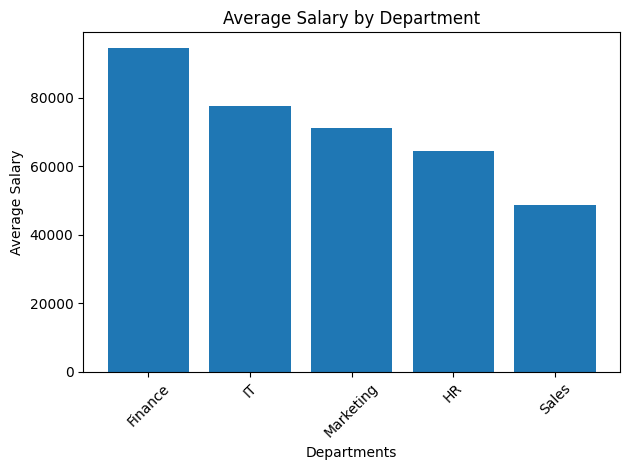

In [40]:
import matplotlib.pyplot as plt
#average salary per department
average_salary_per_department = (
    df.groupby("Department")["Salary"]
      .mean()
      .round(2)
      .sort_values(ascending=False)
)

print("Department-wise Average Salary : \n", average_salary_per_department, "\n")

plt.bar(average_salary_per_department.index, average_salary_per_department.values)
plt.title("Average Salary by Department")
plt.xlabel("Departments")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("average_salary_department.png", dpi=300)
plt.show()

## Employee Count by Department

### Business Question

Which department has the highest number of employees?

### Business Insights

* Sales has the largest workforce with 4 employees.
* Finance, HR, and IT each have 3 employees, while Marketing has 2 employees.
* A larger workforce does not necessarily indicate higher salaries or better employee retention.
* Workforce planning should consider business needs, workload, and future hiring requirements rather than employee count alone.


Number of Employees per Department : 
 Department
Sales        4
Finance      3
HR           3
IT           3
Marketing    2
dtype: int64


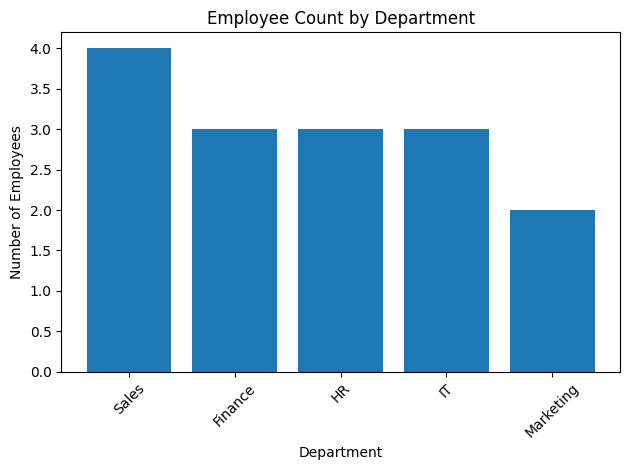

In [41]:
# Counting number of employees in each department
employee_count_per_department = df.groupby("Department").size().sort_values(ascending=False)
print("Number of Employees per Department : \n", employee_count_per_department)

plt.bar(employee_count_per_department.index,
        employee_count_per_department.values)

plt.title("Employee Count by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("employee_count_per_department.png", dpi=300)
plt.show()

# Employee Attrition Analysis

## Overall Attrition

### Business Insights

* Overall employee attrition is 33%, while 67% of employees were retained during the analysis period.
* The majority of employees remain with the organization, indicating moderate overall retention.
* Management should continue monitoring attrition trends to identify changes over time.

---

## Department-wise Attrition

### Business Insights

* Sales department has the highest attrition rate (75%), followed by HR (66.67%).
* Finance, IT, and Marketing reported no employee attrition in the current dataset.
* The higher attrition in Sales and HR suggests these departments require further investigation.
* Additional factors such as salary, overtime, workload, promotions, and job satisfaction should be analyzed before determining the root causes.

---

## Overtime vs Attrition

### Business Insights

* Employees who work overtime have a higher attrition rate (42.86%) than employees who do not work overtime (25%).
* This suggests that overtime may be associated with increased employee turnover.
* Management should review overtime policies, workload distribution, and work-life balance initiatives to improve retention.

---

## Experience vs Salary

### Business Insights

* Employee experience and salary show a strong positive correlation (0.84).
* In general, employees with more experience receive higher salaries.
* Management should periodically review compensation to ensure salaries remain aligned with employee experience, skills, and performance.

---

## Job Satisfaction vs Attrition

### Business Insights

* Employees with low job satisfaction have the highest attrition rate.
* Employees with medium and high job satisfaction show significantly lower attrition.
* Improving job satisfaction through career development, employee engagement, recognition, and work-life balance may help reduce employee turnover.

---

## Promotion vs Attrition

### Business Insights

* Employees who did not receive promotions have a higher attrition rate (56%) than employees who received promotions (0%).
* In the current dataset, no promoted employee left the organization.
* Promotions may be associated with better employee retention, although additional data would be required to establish a causal relationship.
* Management should continue evaluating career growth opportunities alongside other retention factors such as salary, overtime, and job satisfaction.


Overall Attrition Rate: 33.33% 


 Department Wise Attrition Rate : 
 Department
Sales        75.00
HR           66.67
Finance       0.00
IT            0.00
Marketing     0.00
Name: Attrition_Flag, dtype: float64


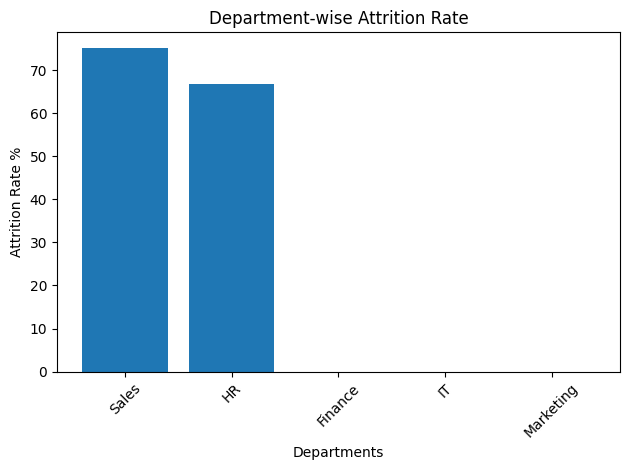


 Attrition Rate by Overtime : 
 Overtime
Yes    42.86
No     25.00
Name: Attrition_Flag, dtype: float64


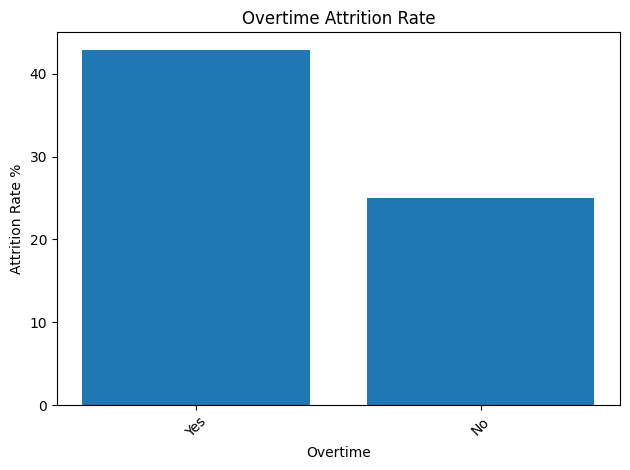


 Relationship Between Experience and Salary: 0.84


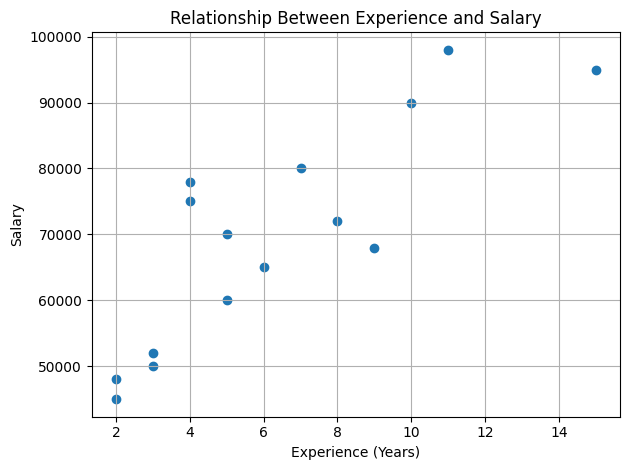


 Job Satisfaction VS Attrition Rate : 
 JobSatisfaction
Low       100.0
Medium     20.0
High       14.0
Name: Attrition_Flag, dtype: float64 



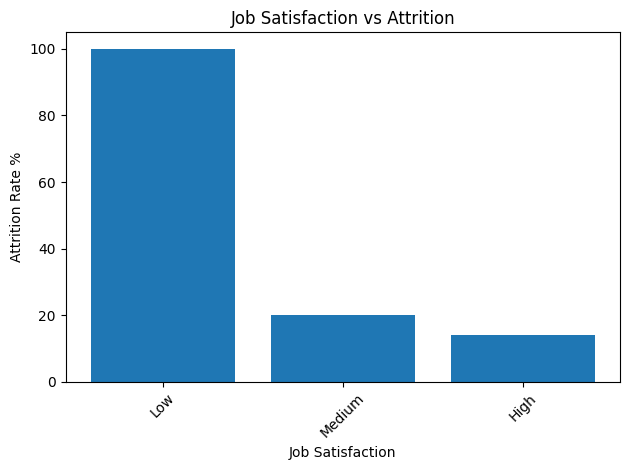


 Attrition Rate by Promotion : 
 Promotion
No     56.0
Yes     0.0
Name: Attrition_Flag, dtype: float64 



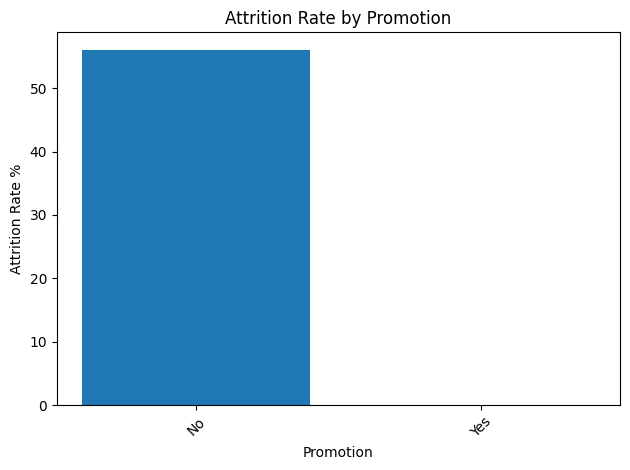

In [42]:
df["Attrition_Flag"] = df["Attrition"].map({"Yes": 1, "No": 0})

#Overall Attition Rate
overall_attrition_rate = (
    df["Attrition_Flag"]
      .mean()
      * 100
)

print(f"Overall Attrition Rate: {overall_attrition_rate:.2f}% \n")

#Department Wise Attrition Rate
department_attrition = ( df.groupby("Department")["Attrition_Flag"] .mean() .mul(100) .round(2) .sort_values(ascending=False) )
print("\n Department Wise Attrition Rate : \n", department_attrition)

plt.bar(department_attrition.index, department_attrition.values)
plt.title("Department-wise Attrition Rate")
plt.xlabel("Departments")
plt.ylabel("Attrition Rate %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("department_attrition.png", dpi=300)
plt.show()


#overtime attrition rate
overtime_attrition_rate = df.groupby("Overtime")["Attrition_Flag"].mean().mul(100).round(2).sort_values(ascending=False)
print("\n Attrition Rate by Overtime : \n", overtime_attrition_rate)

plt.bar(overtime_attrition_rate.index, overtime_attrition_rate.values)
plt.title("Overtime Attrition Rate")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("overtime_attrition_rate.png", dpi=300)
plt.show()


# Calculate correlation between experience and salary
experience_salary_corr = df["Experience"].corr(df["Salary"]).round(2)

print("\n Relationship Between Experience and Salary:", experience_salary_corr)

plt.scatter(df["Experience"], df["Salary"])
plt.title("Relationship Between Experience and Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.grid(True)
plt.tight_layout()
plt.savefig("experience_salary_corr.png", dpi=300)
plt.show()


# Calculate attrition rate by Job Satisfaction
job_satisfaction_attrition = df.groupby("JobSatisfaction")["Attrition_Flag"].mean().round(2).mul(100).sort_values(ascending=False)
print("\n Job Satisfaction VS Attrition Rate : \n", job_satisfaction_attrition, "\n")

plt.bar(job_satisfaction_attrition.index, job_satisfaction_attrition.values)
plt.title("Job Satisfaction vs Attrition")
plt.xlabel("Job Satisfaction")
plt.ylabel("Attrition Rate %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("job_satisfaction_attrition.png", dpi=300)
plt.show()


# Are employees who receive promotions less likely to leave the company?
attrition_by_promotion = df.groupby("Promotion")["Attrition_Flag"].mean().round(2).mul(100).sort_values(ascending=False)
print("\n Attrition Rate by Promotion : \n", attrition_by_promotion, "\n")

plt.bar(attrition_by_promotion.index, attrition_by_promotion.values)
plt.title("Attrition Rate by Promotion")
plt.xlabel("Promotion")
plt.ylabel("Attrition Rate %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("attrition_by_promotion.png", dpi=300)
plt.show()

# **Executive Summary**

This HR Analytics project analyzed employee data to identify factors affecting salary, employee retention, and attrition.

The dataset was inspected and cleaned by removing duplicate records and handling missing salary values using the median. After data preparation, exploratory data analysis and visualizations were performed to identify business trends.

The analysis focused on salary distribution, employee count, attrition rate, overtime, job satisfaction, promotions, and the relationship between experience and salary.

## Key Findings


*   Finance department has the highest average salary.
*   Sales department has the highest employee attrition rate.
*   Employees working overtime have a higher attrition rate than employees who do not work overtime.
*   Employees with low job satisfaction show the highest attrition.
*   Employees who received promotions showed no attrition in the current dataset.
*   Experience and salary have a strong positive correlation (0.84).







## Business Recommendations


*   Review employee retention strategies in the Sales department because it has the highest attrition rate.
*   Investigate the causes of low job satisfaction through employee surveys and feedback sessions.
*   Review overtime policies to improve work-life balance.
*   Continue providing career growth opportunities and promotions where appropriate.
*   Periodically review compensation structures to ensure salaries remain competitive and aligned with experience and performance.








This project demonstrates an end-to-end HR Analytics workflow using Python. It covers data loading, data cleaning, exploratory data analysis, visualization, business insights, and recommendations that can support HR decision-making.